# Data Manipulation and Analysis Exercise
Imports

In [14]:
import pandas as pd  # pandas: the library that gives us the DataFrame type + read_csv/read_excel/etc.
import matplotlib.pyplot as plt  # pyplot: the plotting interface used for the histograms in Tasks 3 & 4

## Task 1 — BigmacPrice.csv

In [15]:
df_bigmac = pd.read_csv("BigmacPrice.csv")  # read the CSV (default comma separator, utf-8 encoding) into a DataFrame
df_bigmac.head(10)  # show the first 10 rows so we can see the real column names and sample values

,date,currency_code,name,local_price,dollar_ex,dollar_price
0,2000-04-01,ARS,Argentina,2.50,1,2.50
1,2000-04-01,AUD,Australia,2.59,1,2.59
2,2000-04-01,BRL,Brazil,2.95,1,2.95
3,2000-04-01,GBP,Britain,1.90,1,1.90
4,2000-04-01,CAD,Canada,2.85,1,2.85
5,2000-04-01,CLP,Chile,1260.00,514,2.45
6,2000-04-01,CNY,China,9.90,8,1.24
7,2000-04-01,CZK,Czech Republic,54.37,39,1.39
8,2000-04-01,DKK,Denmark,24.75,8,3.09
9,2000-04-01,EUR,Euro area,2.56,1,2.56


In [16]:
print("shape (rows, columns):", df_bigmac.shape)  # how many rows/columns the DataFrame actually has
df_bigmac.info()  # column names, dtypes, and non-null counts per column -> confirms nothing is missing and types were inferred correctly

shape (rows, columns): (1946, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1946 entries, 0 to 1945
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1946 non-null   object 
 1   currency_code  1946 non-null   object 
 2   name           1946 non-null   object 
 3   local_price    1946 non-null   float64
 4   dollar_ex      1946 non-null   int64  
 5   dollar_price   1946 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 91.3+ KB


In [17]:
df_bigmac.describe()  # summary stats (count, mean, std, min, 25/50/75%, max) for every numeric column

,local_price,dollar_ex,dollar_price
count,1.946000e+03,1.946000e+03,1946.000000
mean,1.581609e+04,4.722255e+03,3.568011
std,3.940050e+05,1.006232e+05,1.417054
min,0.000000e+00,1.000000e+00,0.000000
25%,4.450000e+00,1.000000e+00,2.572500
50%,1.500000e+01,5.000000e+00,3.400000
75%,8.700000e+01,3.200000e+01,4.240000
max,1.602000e+07,3.613989e+06,11.250000


## Task 2 — ChickenData.xlsx

In [18]:
df_chicken = pd.read_excel("ChickenData.xlsx")  # read the .xlsx sheet into a DataFrame (pandas auto-picks the openpyxl engine for .xlsx)
df_chicken.head(10)  # preview the first 10 rows -> lets us confirm the real column names before referencing them below

,chicken_id,weight,breed,eggs_per_year
0,1,2728.854920,New Hampshire Red,158
1,2,2323.761365,Australorp,273
2,3,2635.062034,New Hampshire Red,153
3,4,2603.985152,Plymouth Rock,268
4,5,3079.394487,Australorp,360
5,6,2250.163583,Barnevelder,317
6,7,2648.364847,Plymouth Rock,158
7,8,2371.107826,New Hampshire Red,275
8,9,2224.379423,Barnevelder,169
9,10,2577.250189,Plymouth Rock,340


In [19]:
print("shape (rows, columns):", df_chicken.shape)  # total row/column count
df_chicken.info()  # column names, dtypes, non-null counts -> check for missing values / wrong types

shape (rows, columns): (100, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   chicken_id     100 non-null    int64  
 1   weight         100 non-null    float64
 2   breed          100 non-null    object 
 3   eggs_per_year  100 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 3.3+ KB


In [20]:
print("rows:", len(df_chicken))  # one row per chicken
print("unique breeds:", df_chicken["breed"].nunique())  # how many DISTINCT breed values exist
df_chicken["breed"].value_counts()  # count of rows (chickens) per breed -> shows several chickens share the same breed

rows: 100
unique breeds: 5


breed
Australorp           23
Plymouth Rock        22
Barnevelder          21
New Hampshire Red    20
ISA Brown            14
Name: count, dtype: int64

In [21]:
dict_chicken = dict(zip(df_chicken["breed"], df_chicken["eggs_per_year"]))
# zip(breed_column, eggs_column) pairs up each row's breed with that row's eggs_per_year, one (breed, eggs) tuple per row
# dict(...) turns those tuples into key -> value pairs; dict keys must be UNIQUE, so when several
# rows share the same breed, only the LAST row's eggs_per_year for that breed survives in the dict

print(f"Built dict with {len(dict_chicken)} breeds")  # len(dict) == number of unique breed keys (5), NOT the 100 rows we started with
dict(list(dict_chicken.items())[:5])  # peek at the first 5 (key, value) pairs, wrapped back into a small dict for display

Built dict with 5 breeds


{'New Hampshire Red': 297,
 'Australorp': 213,
 'Plymouth Rock': 314,
 'Barnevelder': 316,
 'ISA Brown': 225}

## Task 3 — Cars_autoscout24.csv

In [22]:
# utf-8 raises UnicodeDecodeError on this file (accented characters in car names, e.g. "El\u00e9gance") -> latin1 instead.
# Separator is ';', not ',' (this is a European/Swiss export format).
try:
    df_cars = pd.read_csv("Cars_autoscout24.csv", sep=";", encoding="utf-8")  # first attempt, as the task instructs to try
except UnicodeDecodeError as e:  # utf-8 can't decode a byte it doesn't recognise -> catch specifically that error
    print("utf-8 failed:", e)  # show exactly why utf-8 didn't work
    df_cars = pd.read_csv("Cars_autoscout24.csv", sep=";", encoding="latin1")  # latin1 (ISO-8859-1) accepts every byte value, so it never raises here
df_cars.head(10)  # preview the first 10 rows now that the file is loaded correctly

utf-8 failed: 'utf-8' codec can't decode byte 0xe9 in position 22: invalid continuation byte


,Offer_Id,Type,Price,PS,Init_Regist,Kilometer,Fuel_Type,Transmission
0,7324420,AUDI A5 Sportback 3.0 TDI quattro S-tronic (Li...,CHF 22'500.,245 PS,10.2014,75'000 km,Diesel,Automatisiertes Schaltgetriebe
1,7512768,MERCEDES-BENZ SLK 200 7G-Tronic (Cabriolet),CHF 23'749.,184 PS,6.2013,46'655 km,Benzin,Automat sequentiell
2,7512034,MERCEDES-BENZ C 350 Avantgarde 4Matic 7G-Troni...,CHF 18'500.,306 PS,6.2011,138'955 km,Benzin,Automat sequentiell
3,7512728,MERCEDES-BENZ A 45 AMG 4Matic Speedshift 7G-DC...,CHF 36'000.,360 PS,8.2015,43'000 km,Benzin,Automatisiertes Schaltgetriebe
4,7490242,AUDI A5 Sportback 2.0 TFSI Sport quattro S-tro...,CHF 48'500.,252 PS,9.2018,43'300 km,Benzin,Automatisiertes Schaltgetriebe
5,7512188,MERCEDES-BENZ SLK 200 Kompressor (Cabriolet),CHF 12'000.,163 PS,12.2004,109'000 km,Benzin,Schaltgetriebe manuell
6,7512184,MERCEDES-BENZ C 350 Elégance Sport Edition 4Ma...,CHF 8'000.,272 PS,5.2006,156'000 km,Benzin,Automat
7,7512142,SEAT Ibiza SC 1.4 TSI Cupra DSG (Kleinwagen),CHF 10'500.,180 PS,2.201,71'400 km,Benzin,Automatisiertes Schaltgetriebe
8,7511265,PORSCHE 911 Turbo Cabrio PDK (Cabriolet),CHF 143'500.,521 PS,7.2015,18'000 km,Benzin,Automatisiertes Schaltgetriebe
9,7511230,VW Golf 1.4 TSI Comfortline (Limousine),CHF 19'800.,125 PS,12.2015,110'000 km,Benzin,Schaltgetriebe manuell


In [23]:
# Price values look like "CHF 22'500.\u2013" (currency prefix, apostrophe as thousands separator,
# trailing dash standing in for ".00" since no cents are given). We just want the plain number.
df_cars["Prices_numeric"] = df_cars["Price"].str.replace(r"[^\d]", "", regex=True).astype(float)
# .str.replace(r"[^\d]", "", regex=True): regex "[^\d]" matches any character that is NOT a digit,
#   and replaces every match with "" (i.e. deletes it) -> "CHF 22'500.\u2013" becomes "22500"
# .astype(float): converts the now-numeric-looking strings into actual float values
df_cars["Prices_numeric"].head(10)  # preview the converted column to sanity-check the cleaning worked

0     22500.0
1     23749.0
2     18500.0
3     36000.0
4     48500.0
5     12000.0
6      8000.0
7     10500.0
8    143500.0
9     19800.0
Name: Prices_numeric, dtype: float64

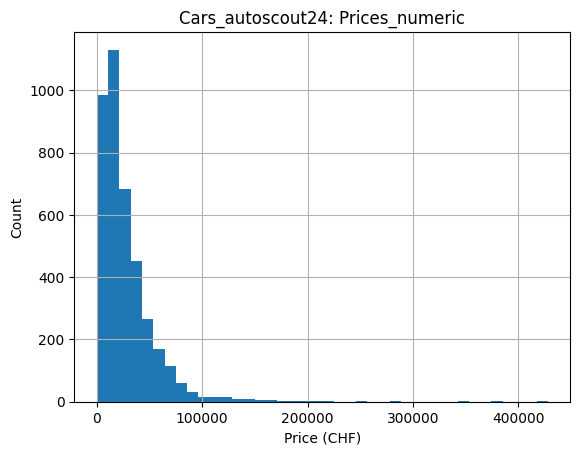

In [24]:
df_cars["Prices_numeric"].hist(bins=40)  # draw a histogram of the price distribution, split into 40 bins
plt.xlabel("Price (CHF)")  # label the x-axis
plt.ylabel("Count")  # label the y-axis (number of cars per bin)
plt.title("Cars_autoscout24: Prices_numeric")  # chart title
plt.show()  # render the figure

In [25]:
price_min = df_cars["Prices_numeric"].min()  # smallest price in the (full) dataset
price_max = df_cars["Prices_numeric"].max()  # largest price in the (full) dataset
price_mean = df_cars["Prices_numeric"].mean()  # average price across all rows
print(f"min={price_min}, max={price_max}, mean={price_mean:.2f}")  # :.2f formats the mean to 2 decimal places

min=160.0, max=428000.0, mean=27678.18


## Task 4 — Personalized subset analysis

In [26]:
# Birth month: February = 2 (even) -> Fuel_Type == 'Benzin'
birth_month = 2  # plug in the real birth month here (1-12)
last_digit = birth_month % 10  # % is the modulo operator: remainder after dividing by 10 -> the month's last digit
fuel_type = "Benzin" if birth_month % 2 == 0 else "Diesel"  # even month -> Benzin, odd month -> Diesel (birth_month % 2 == 0 checks evenness)
print(f"birth_month={birth_month}, last_digit={last_digit}, fuel_type={fuel_type}")

df_subset = df_cars[df_cars["Fuel_Type"] == fuel_type].copy()
# df_cars["Fuel_Type"] == fuel_type: builds a True/False mask, one value per row, True where Fuel_Type matches
# df_cars[mask]: keeps only the rows where the mask is True
# .copy(): makes an independent copy, so editing df_subset below doesn't trigger pandas' SettingWithCopyWarning on df_cars
df_subset["Prices_numeric"] = df_subset["Price"].str.replace(r"[^\d]", "", regex=True).astype(float)
# same cleaning as Task 3, redone here because it must be recomputed ON the filtered subset
df_subset.shape  # (row_count, column_count) of the filtered subset

birth_month=2, last_digit=2, fuel_type=Benzin


(2654, 9)

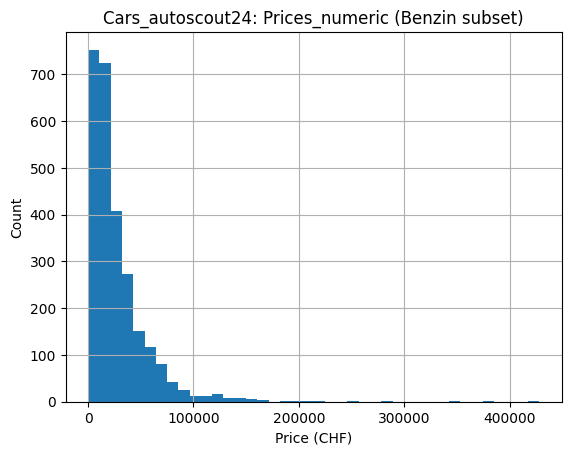

In [27]:
df_subset["Prices_numeric"].hist(bins=40)  # histogram of prices, subset only
plt.xlabel("Price (CHF)")  # x-axis label
plt.ylabel("Count")  # y-axis label
plt.title(f"Cars_autoscout24: Prices_numeric ({fuel_type} subset)")  # f-string inserts the actual fuel_type into the title
plt.show()  # render the figure

In [28]:
subset_mean = df_subset["Prices_numeric"].mean()  # average price within the filtered subset only
print(f"last_digit={last_digit}, fuel_type={fuel_type}, subset_mean_price={subset_mean:.2f}")  # the 3 values Task 4 asks you to report

last_digit=2, fuel_type=Benzin, subset_mean_price=28042.48
